# E3 — Entrenamiento PCN v3

Entrenamiento desde cero con hiperparámetros corregidos:
- **400 épocas** (v1 = 100, v2 = 300 con bug de loss)
- **LR decay cada 100 épocas** (v1 era cada 40 → decaía demasiado rápido)
- **w_coarse = 0.5** (igual que v1, para que las métricas sean comparables)
- **Batch 64** — T4 lo aguanta bien

⏱️ **Tiempo estimado en T4: ~3.5 horas**

---
### Antes de ejecutar:
Menú → **Entorno de ejecución → Cambiar tipo de entorno de ejecución → T4 GPU**

---
### Celdas opcionales:
- **Celda 7**: evalúa el modelo v2 (`epoch_300.pt`) antes de entrenar — útil para comparar
- **Celda 9**: cambia `--epochs 400` por menos épocas para un test rápido

In [1]:
# ── CELDA 1: Montar Drive ──────────────────────────────────────
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# ── CELDA 2: Clonar repo e instalar dependencias ───────────────
# El repo es privado → necesitas un token de GitHub.
#
# Cómo crear el token (1 sola vez):
#   GitHub → tu foto → Settings → Developer settings
#   → Personal access tokens → Tokens (classic) → Generate new token
#   → Selecciona solo 'repo' → Generate → copia el token (empieza por ghp_)

import os
from getpass import getpass

REPO_DIR = '/content/TFM'

if not os.path.exists(REPO_DIR):
    token = getpass('Pega tu token de GitHub (ghp_...) y pulsa Enter: ')
    repo_url = f'https://{token}@github.com/herredoble/TFM-reconstruccion-3D'
    os.system(f'git clone {repo_url} {REPO_DIR}')
    del token
else:
    os.system(f'git -C {REPO_DIR} pull')

os.chdir(REPO_DIR)
os.system('git checkout raquel/e3')
print('Directorio de trabajo:', os.getcwd())

import subprocess
subprocess.run(['pip', 'install', 'torch', 'numpy', 'matplotlib', '--quiet'])
print('Dependencias instaladas.')

Pega tu token de GitHub (ghp_...) y pulsa Enter: ··········
Directorio de trabajo: /content/TFM
Dependencias instaladas.


In [3]:
# ── CELDA 3: RUTAS DE DRIVE ────────────────────────────────────
# Si quieres cambiar a otro Drive, solo cambia DRIVE.
# Estructura en Drive:
#   Datos_E2_E3/E3/Raquel/modelos/<version>/    ← checkpoints .pt
#   Datos_E2_E3/E3/Raquel/resultados/<version>/ ← métricas + figuras

DRIVE   = '/content/drive/MyDrive'
BASE_E3 = f'{DRIVE}/Datos_E2_E3/E3/Raquel'   # carpeta de Raquel dentro de E3

# Versión de este entrenamiento (cambia aquí si lanzas otro experimento)
VERSION = 'v3_pcn'

# Datos de entrenamiento (compartidos, fuera de Raquel/)
RUTA_SINTETICO    = f'{DRIVE}/Datos_E2_E3/General/sintetico_roturas'
RUTA_FB_PROCESADO = f'{DRIVE}/Datos_E2_E3/General/Fantastik_Break_Preprocesado'

# Modelo de referencia v2 (para evaluar antes de entrenar v3)
RUTA_MODELO_V2 = f'{BASE_E3}/modelos/v2_pcn/epoch_300.pt'

# Dónde guardar el modelo y resultados de esta versión
RUTA_SALIDA_MODELO     = f'{BASE_E3}/modelos/{VERSION}'
RUTA_SALIDA_RESULTADOS = f'{BASE_E3}/resultados/{VERSION}'

print('Rutas configuradas:')
print(f'  sintetico       : {RUTA_SINTETICO}')
print(f'  fantastic_breaks: {RUTA_FB_PROCESADO}')
print(f'  modelo v2       : {RUTA_MODELO_V2}')
print(f'  salida modelo   : {RUTA_SALIDA_MODELO}')
print(f'  salida resultados: {RUTA_SALIDA_RESULTADOS}')

Rutas configuradas:
  sintetico       : /content/drive/MyDrive/Datos_E2_E3/General/sintetico_roturas
  fantastic_breaks: /content/drive/MyDrive/Datos_E2_E3/General/Fantastik_Break_Preprocesado
  modelo v2       : /content/drive/MyDrive/Datos_E2_E3/E3/Raquel/modelos/v2_pcn/epoch_300.pt
  salida modelo   : /content/drive/MyDrive/Datos_E2_E3/E3/Raquel/modelos/v3_pcn
  salida resultados: /content/drive/MyDrive/Datos_E2_E3/E3/Raquel/resultados/v3_pcn


In [4]:
# ── CELDA 4: Verificar que las rutas existen ───────────────────
from pathlib import Path

rutas = {
    'sintetico_roturas'      : RUTA_SINTETICO,
    'fantastic_breaks'       : RUTA_FB_PROCESADO,
    'modelo_v2 (epoch_300)'  : RUTA_MODELO_V2,
}

ok = True
for nombre, ruta in rutas.items():
    existe = Path(ruta).exists()
    emoji  = '✅' if existe else '❌'
    print(f'  {emoji} {nombre}: {ruta}')
    if not existe:
        ok = False

if ok:
    print('\nTodo encontrado. Puedes continuar.')
else:
    print('\n⚠️  Alguna ruta no existe. Revisa el Drive antes de continuar.')

  ✅ sintetico_roturas: /content/drive/MyDrive/Datos_E2_E3/General/sintetico_roturas
  ✅ fantastic_breaks: /content/drive/MyDrive/Datos_E2_E3/General/Fantastik_Break_Preprocesado
  ❌ modelo_v2 (epoch_300): /content/drive/MyDrive/Datos_E2_E3/E3/Raquel/modelos/v2_pcn/epoch_300.pt

⚠️  Alguna ruta no existe. Revisa el Drive antes de continuar.


In [5]:
# ── CELDA 5: Copiar datos desde Drive ─────────────────────────
import subprocess
from pathlib import Path

def copiar_dir(src, dst):
    """Copia carpeta de Drive evitando bucles de shortcuts/symlinks."""
    src, dst = Path(src), Path(dst)
    if dst.exists() and any(dst.glob('*.npy')):
        n = len(list(dst.glob('*.npy')))
        print(f'  [OK] ya existe: {dst.name}  ({n} .npy)')
        return
    if not src.exists():
        print(f'  [ERROR] no encontrado: {src}')
        return
    dst.mkdir(parents=True, exist_ok=True)
    print(f'  Copiando {src.name} (puede tardar varios minutos)...', flush=True)
    r = subprocess.run(['rsync', '-a', '--no-links', f'{src}/', str(dst)],
                       capture_output=True, text=True)
    if r.returncode != 0:
        print(f'  [ERROR rsync] {r.stderr[:300]}')
    else:
        n = len(list(dst.glob('*.npy')))
        print(f'  listo — {n} archivos .npy copiados.')

copiar_dir(RUTA_SINTETICO,    'Datos/sintetico/roturas')
copiar_dir(RUTA_FB_PROCESADO, 'Datos/fantastic_breaks/procesado')

print()
for c in ['Datos/sintetico/roturas', 'Datos/fantastic_breaks/procesado']:
    n = len(list(Path(c).glob('*.npy'))) if Path(c).exists() else 0
    print(f'  {c}: {n} .npy')

  Copiando sintetico_roturas (puede tardar varios minutos)...
  listo — 4602 archivos .npy copiados.
  Copiando Fantastik_Break_Preprocesado (puede tardar varios minutos)...
  listo — 122 archivos .npy copiados.

  Datos/sintetico/roturas: 4602 .npy
  Datos/fantastic_breaks/procesado: 122 .npy


In [6]:
# ── CELDA 6: Verificar GPU ─────────────────────────────────────
import torch
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    print(f'VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')
else:
    print('⚠️  Sin GPU. Ve a Entorno de ejecución → Cambiar tipo → T4 GPU')

GPU: NVIDIA A100-SXM4-40GB
VRAM: 42.4 GB


In [7]:
# ── CELDA 7 [OPCIONAL]: Evaluar modelo v2 antes de entrenar v3 ─
# Ejecuta esto primero para ver si epoch_300.pt mejoró sobre v1 (CD=0.077).
# Si el CD baja → v2 es mejor que v1. Si no → v3 parte de cero igualmente.

import shutil
from pathlib import Path

# Copia epoch_300.pt de Drive al directorio de trabajo
Path('E3/checkpoints').mkdir(parents=True, exist_ok=True)
shutil.copy2(RUTA_MODELO_V2, 'E3/checkpoints/best.pt')
print(f'Cargado: {RUTA_MODELO_V2}')

!python -m E3.evaluate \
    --checkpoint E3/checkpoints/best.pt \
    --salida     E3/resultados_v2

# Guardar resultados v2 en Drive
import shutil, time
RUTA_SALIDA_V2 = f'{BASE_E3}/resultados/v2_pcn'
Path(RUTA_SALIDA_V2).mkdir(parents=True, exist_ok=True)
shutil.copytree('E3/resultados_v2', RUTA_SALIDA_V2, dirs_exist_ok=True)
print(f'Resultados v2 guardados en Drive: {RUTA_SALIDA_V2}')

FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/Datos_E2_E3/E3/Raquel/modelos/v2_pcn/epoch_300.pt'

In [8]:
# ── CELDA 8: ENTRENAR v3 (desde cero) ─────────────────────────
# Deja esta celda corriendo (~3.5 horas en T4).
# El progreso aparece línea a línea.
#
# Mejoras respecto a v1 y v2:
#   --epochs 400     → más épocas para que converja bien
#   --lr_decay 100   → decay más lento (v1 era 40 → LR caía demasiado rápido)
#   --w_coarse 0.5   → igual que v1, métricas comparables
#   sin --resume     → entrenamiento limpio desde cero

!python -m E3.train \
    --epochs     400 \
    --lr         1e-4 \
    --lr_decay   100 \
    --batch_size 64 \
    --w_coarse   0.5

Dispositivo: cuda

=== Dataset E3 ===
  Total pares    : 2362
  Train          : 1889 (80%)
  Val            : 236   (10%)
  Test           : 237  (10%)
  Batch size     : 64
  Augmentación   : True
Parámetros entrenables: 5,157,379
Salida: coarse (512 pts) + fine (2048 pts)

  Época       Train         Val         LR   Tiempo
----------------------------------------------------
   1/400    0.327021    0.359189   1.00e-04     4.6s
  → best.pt guardado (val=0.359189)
   2/400    0.234947    0.239293   1.00e-04     3.2s
  → best.pt guardado (val=0.239293)
   3/400    0.218308    0.219478   1.00e-04     3.2s
  → best.pt guardado (val=0.219478)
   4/400    0.206100    0.201726   1.00e-04     3.2s
  → best.pt guardado (val=0.201726)
   5/400    0.197481    0.195192   1.00e-04     3.2s
  → best.pt guardado (val=0.195192)
   6/400    0.188502    0.184506   1.00e-04     3.2s
  → best.pt guardado (val=0.184506)
   7/400    0.181805    0.182342   1.00e-04     3.2s
  → best.pt guardado (val=0.182

In [9]:
# ── CELDA 9: Guardar modelo en Drive ──────────────────────────
import shutil
from pathlib import Path

Path(RUTA_SALIDA_MODELO).mkdir(parents=True, exist_ok=True)

shutil.copy2('E3/checkpoints/best.pt', f'{RUTA_SALIDA_MODELO}/best.pt')
print(f'Modelo v3 guardado: {RUTA_SALIDA_MODELO}/best.pt')

# También guarda los checkpoints periódicos de las últimas épocas
for ckpt in sorted(Path('E3/checkpoints').glob('epoch_3??.pt')):
    dst = Path(RUTA_SALIDA_MODELO) / ckpt.name
    shutil.copy2(ckpt, dst)
    print(f'  + {ckpt.name}')

Modelo v3 guardado: /content/drive/MyDrive/Datos_E2_E3/E3/Raquel/modelos/v3_pcn/best.pt
  + epoch_300.pt
  + epoch_305.pt
  + epoch_310.pt
  + epoch_315.pt
  + epoch_320.pt
  + epoch_325.pt
  + epoch_330.pt
  + epoch_335.pt
  + epoch_340.pt
  + epoch_345.pt
  + epoch_350.pt
  + epoch_355.pt
  + epoch_360.pt
  + epoch_365.pt
  + epoch_370.pt
  + epoch_375.pt
  + epoch_380.pt
  + epoch_385.pt
  + epoch_390.pt
  + epoch_395.pt


In [10]:
# ── CELDA 10: Evaluar modelo v3 ────────────────────────────────
# Compara el resultado con v1 (CD=0.077, F-Score=0.019).

!python -m E3.evaluate \
    --checkpoint E3/checkpoints/best.pt \
    --salida     E3/resultados

# Guardar resultados en Drive
import shutil
from pathlib import Path

Path(RUTA_SALIDA_RESULTADOS).mkdir(parents=True, exist_ok=True)
shutil.copytree('E3/resultados', RUTA_SALIDA_RESULTADOS, dirs_exist_ok=True)
print(f'Resultados v3 guardados en Drive: {RUTA_SALIDA_RESULTADOS}')

Dispositivo: cuda

=== Dataset E3 ===
  Total pares    : 2362
  Train          : 1889 (80%)
  Val            : 236   (10%)
  Test           : 237  (10%)
  Batch size     : 32
  Augmentación   : False
Muestras en test: 237
Checkpoint: E3/checkpoints/best.pt  (época 347)

=== Evaluación E3 — 237 muestras ===
Checkpoint : E3/checkpoints/best.pt  (época 347)
Nota       : val-loss del entrenamiento = CD(fine) + 0.5·CD(coarse).
             Aquí se reporta solo CD(fine) → número más bajo, es correcto.

Chamfer Distance (CD-L1):
  media    : 0.066536
  mediana  : 0.062840
  std      : 0.021672
  mejor    : 0.028372  (muestra 37)
  peor     : 0.166181  (muestra 193)

F-Score @ τ=0.01:
  media    : 0.0243
  mediana  : 0.0115
  std      : 0.0331
  mejor    : 0.2110  (muestra 33)
  peor     : 0.0000  (muestra 97)

CSV guardado: E3/resultados/metricas.csv

Generando 8 figuras (4 mejores + 4 peores)...
  figura_001_mejor_37.png
  figura_002_mejor_67.png
  figura_003_mejor_33.png
  figura_004_mejor_

=== MEJORES (6) ===
figura_001_mejor_37.png


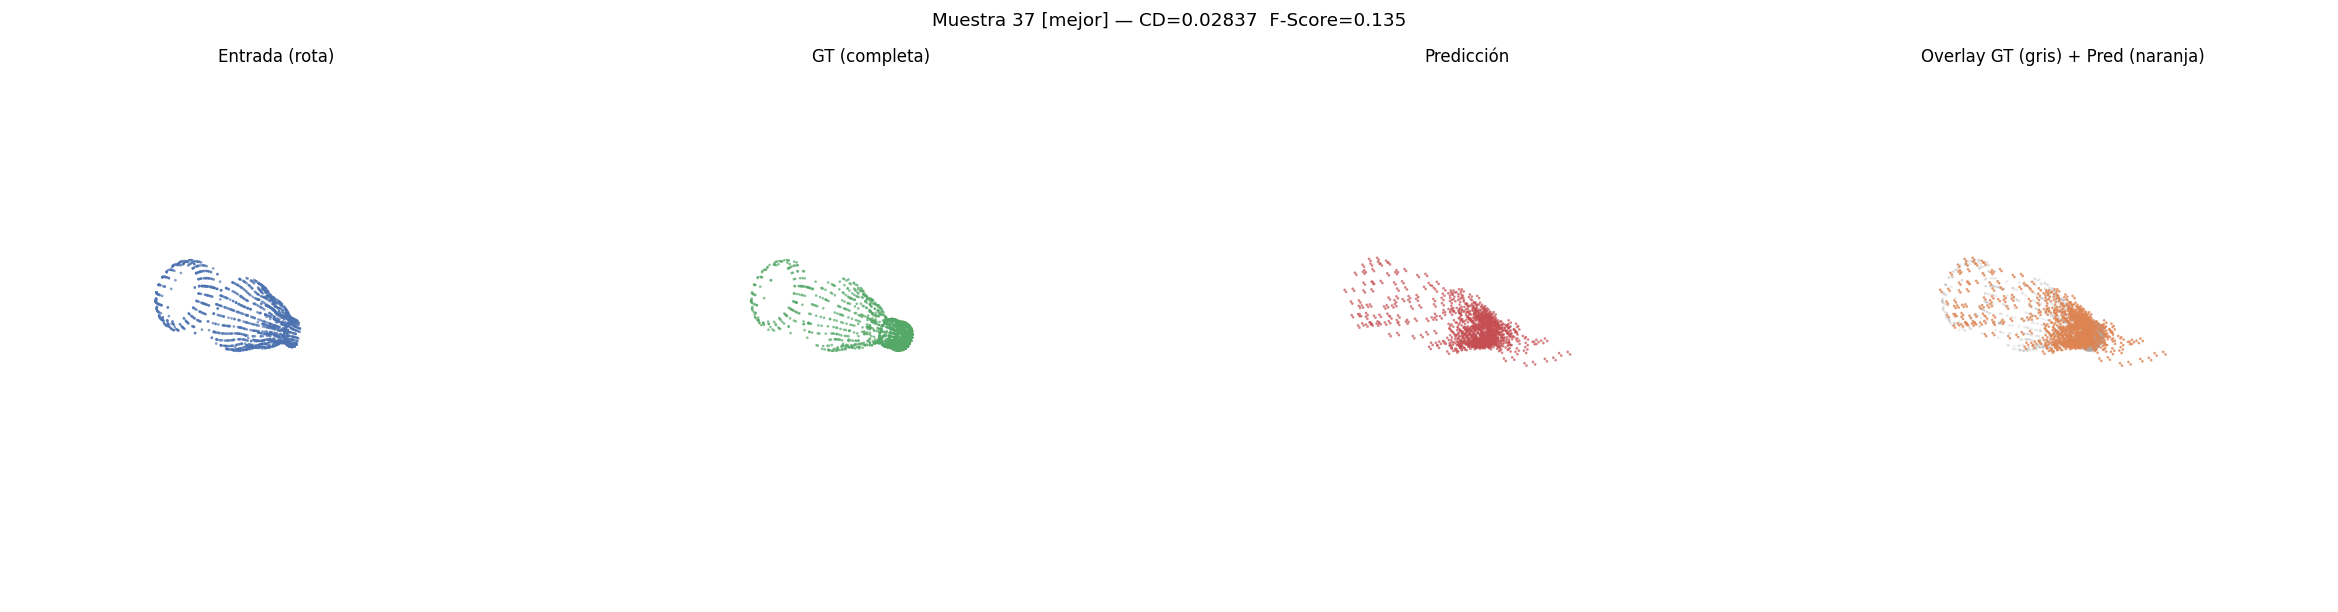

figura_002_mejor_57.png


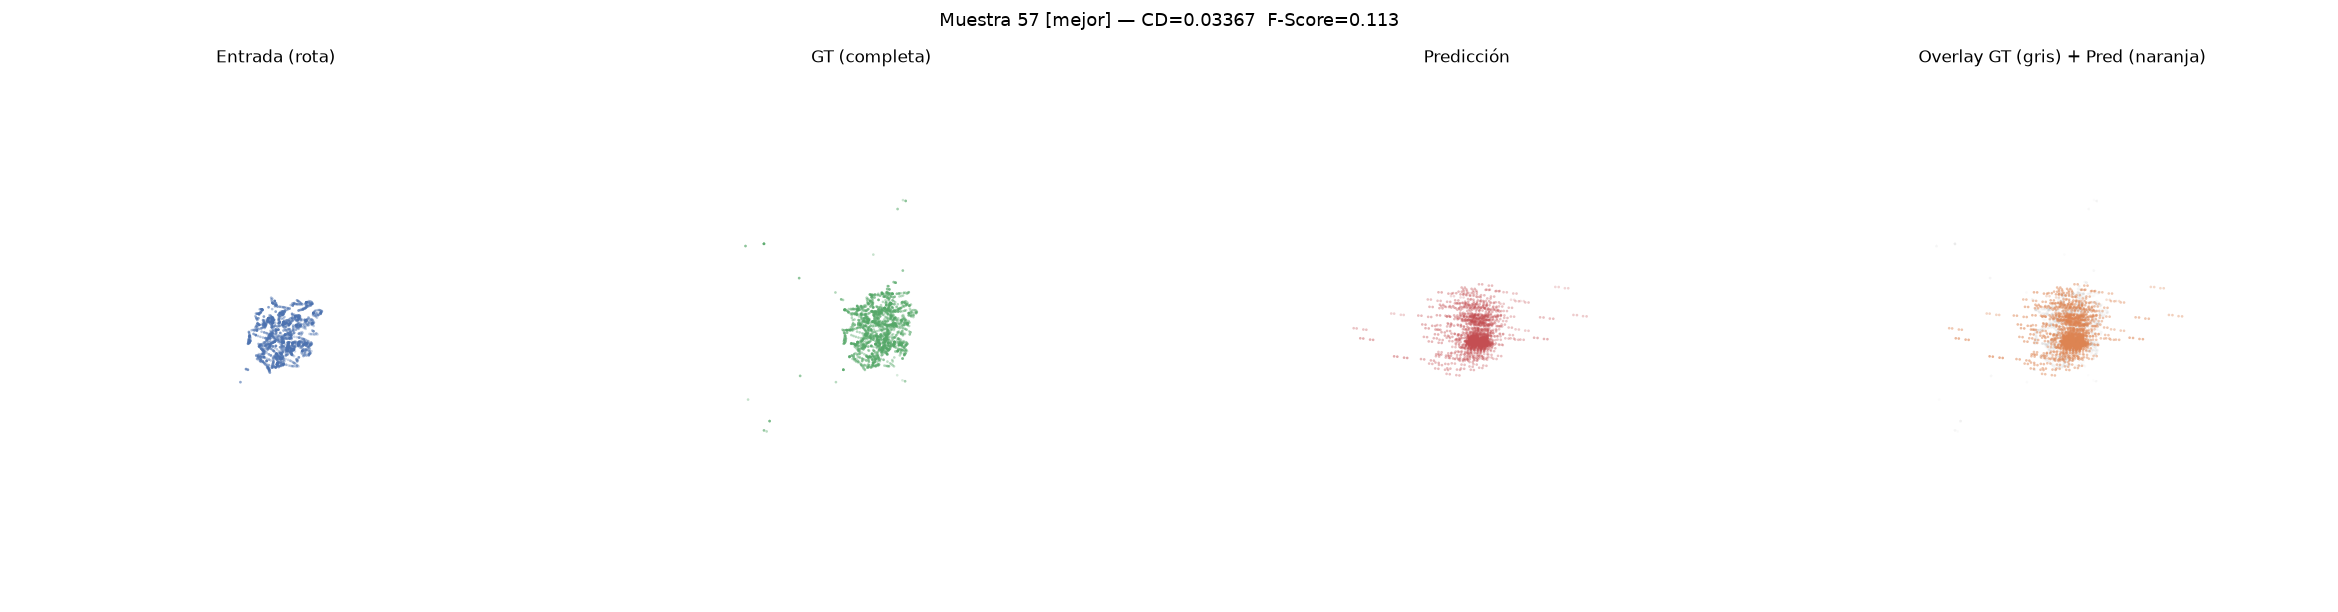

figura_002_mejor_67.png


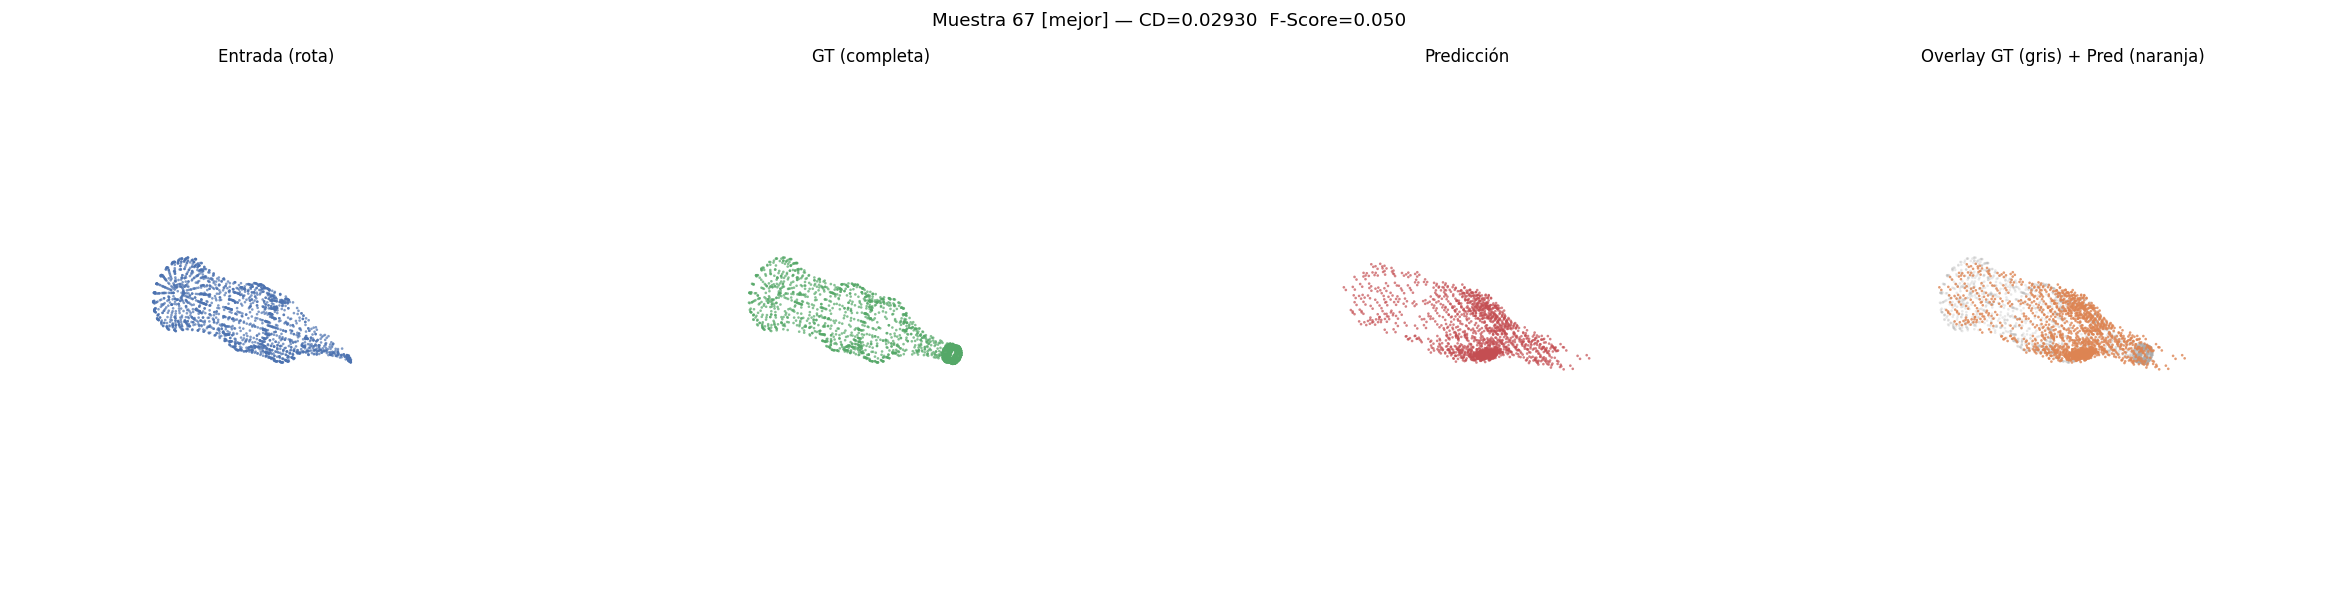

figura_003_mejor_33.png


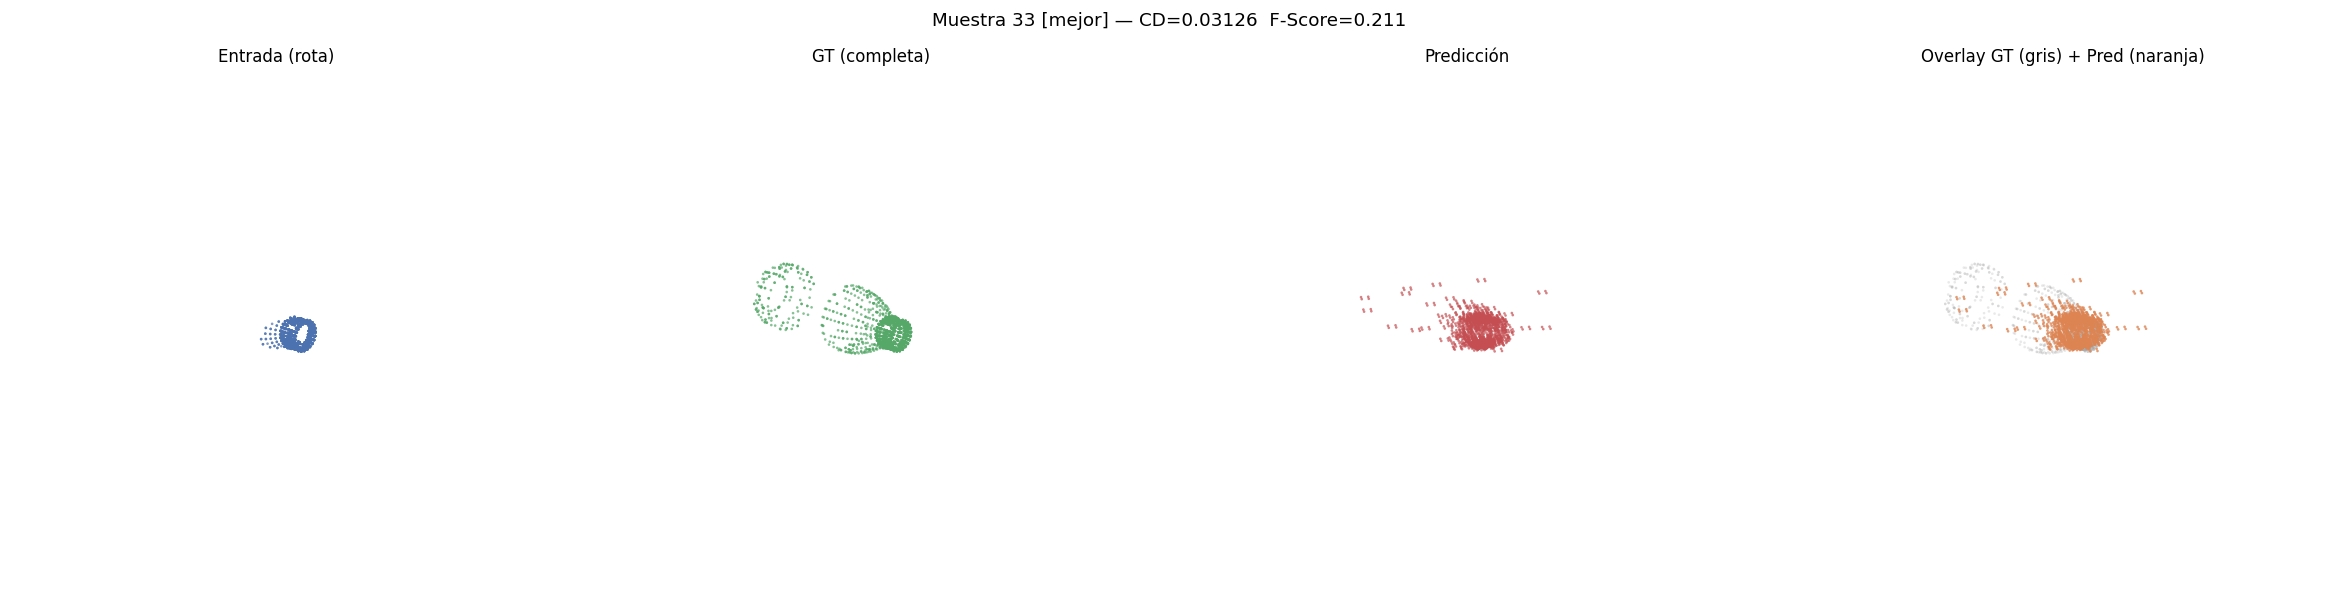

figura_004_mejor_184.png


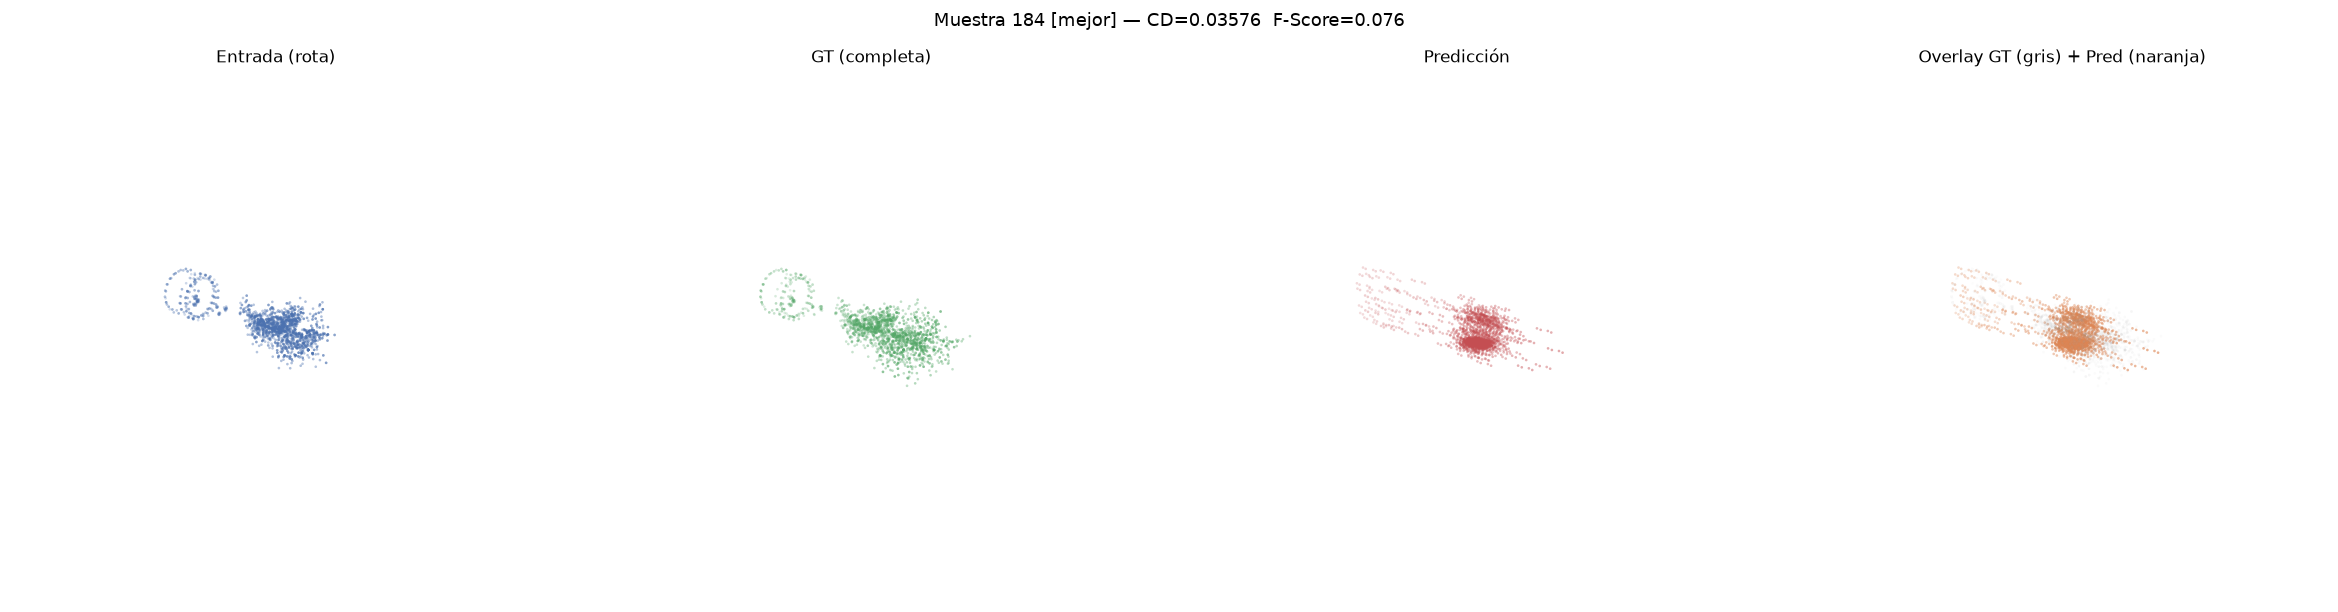

figura_004_mejor_203.png


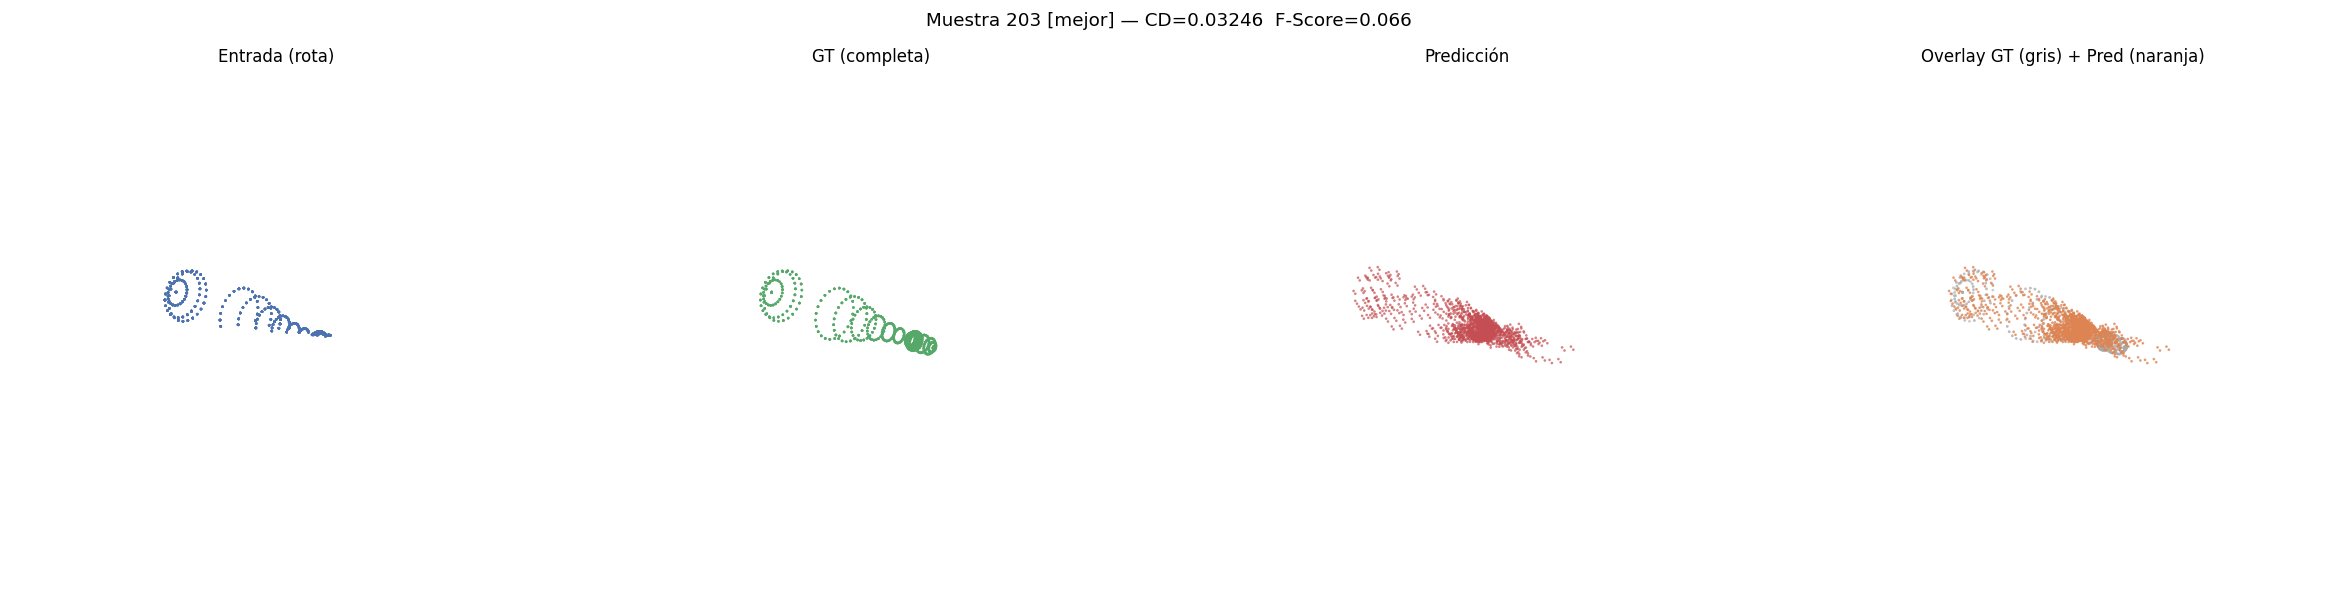


=== PEORES (8) ===
figura_005_peor_172.png


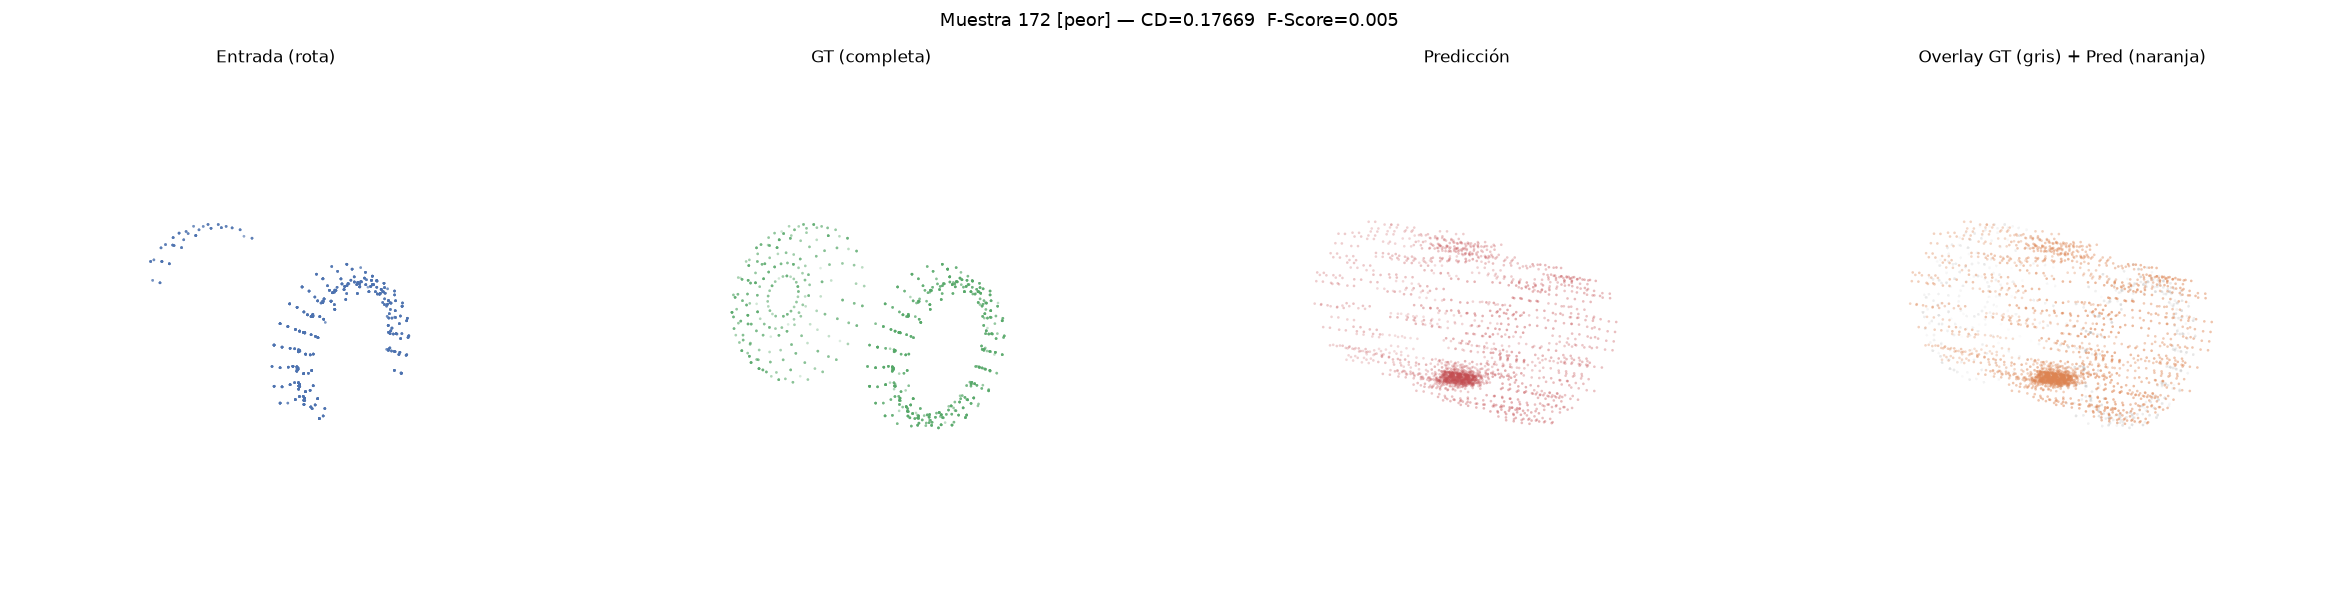

figura_005_peor_97.png


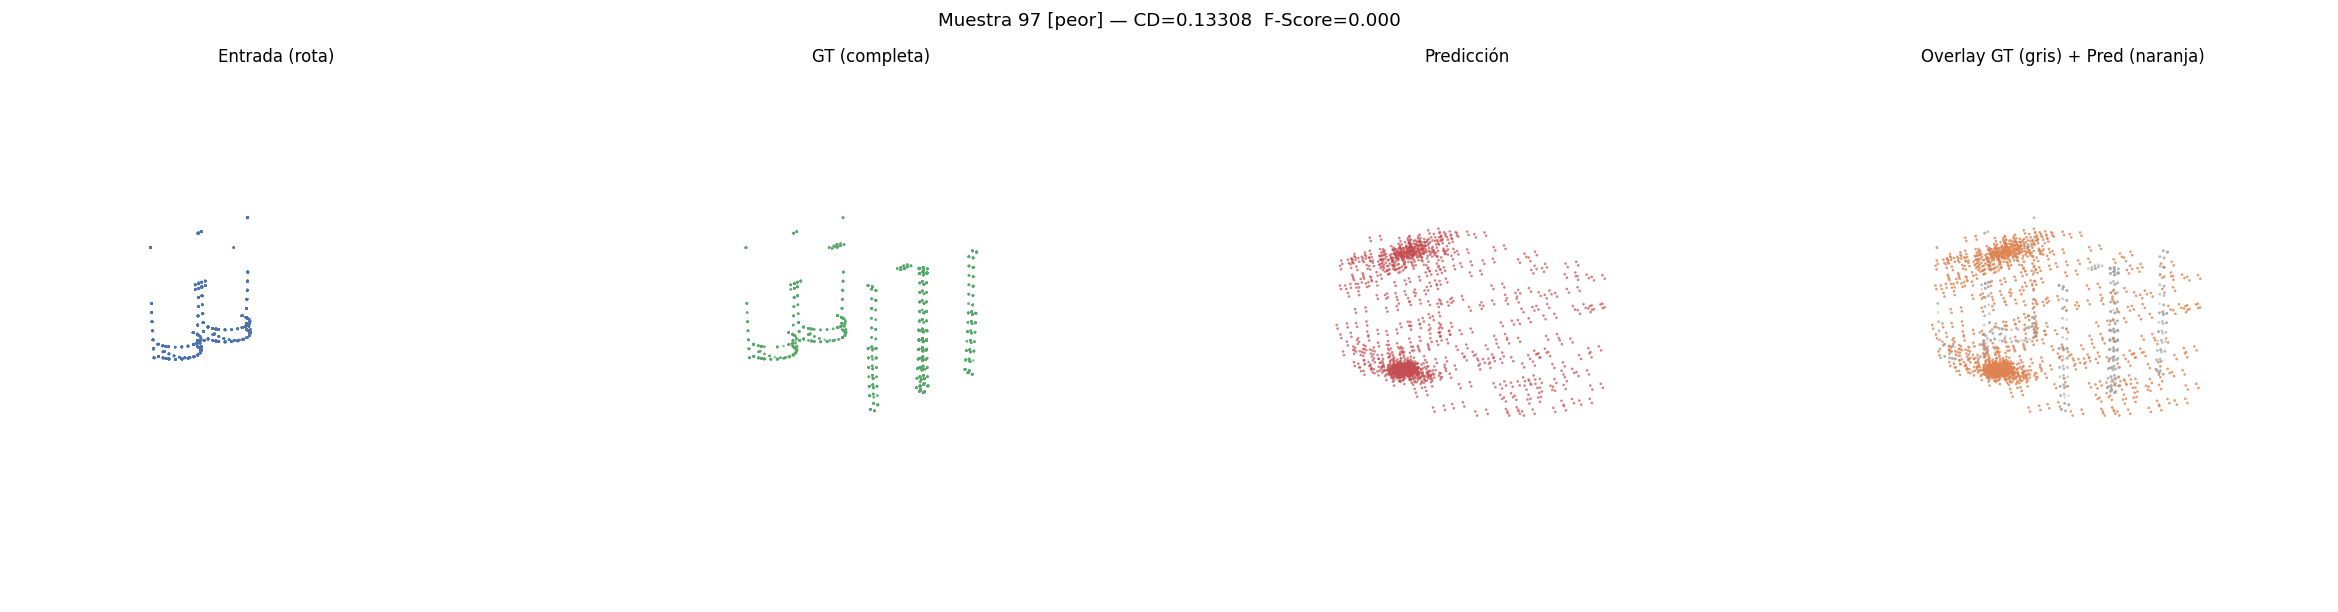

figura_006_peor_150.png


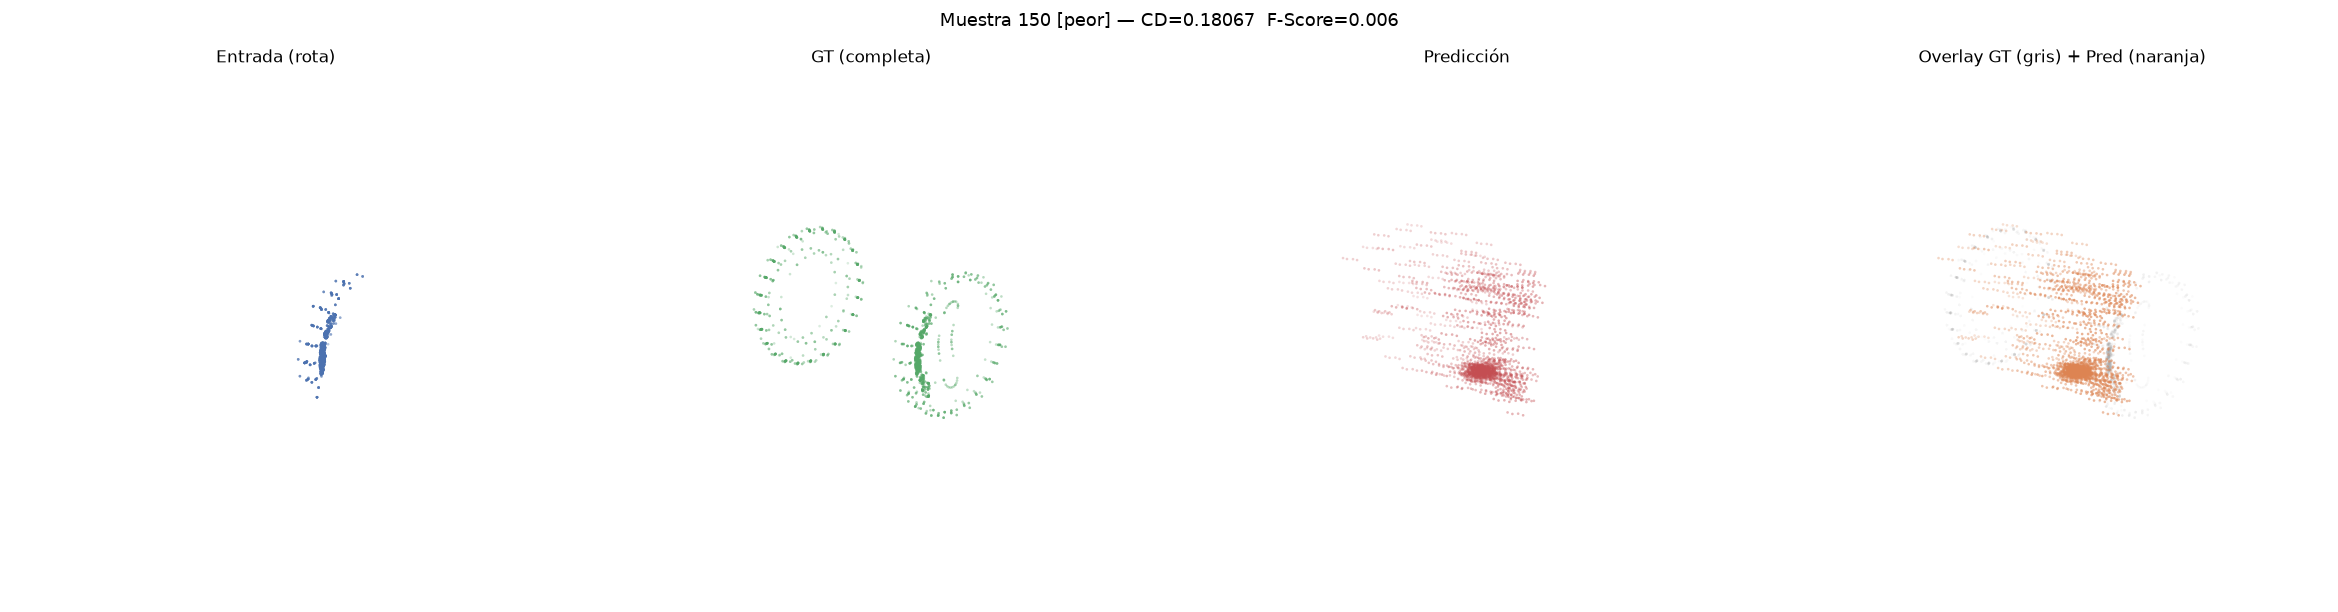

figura_006_peor_188.png


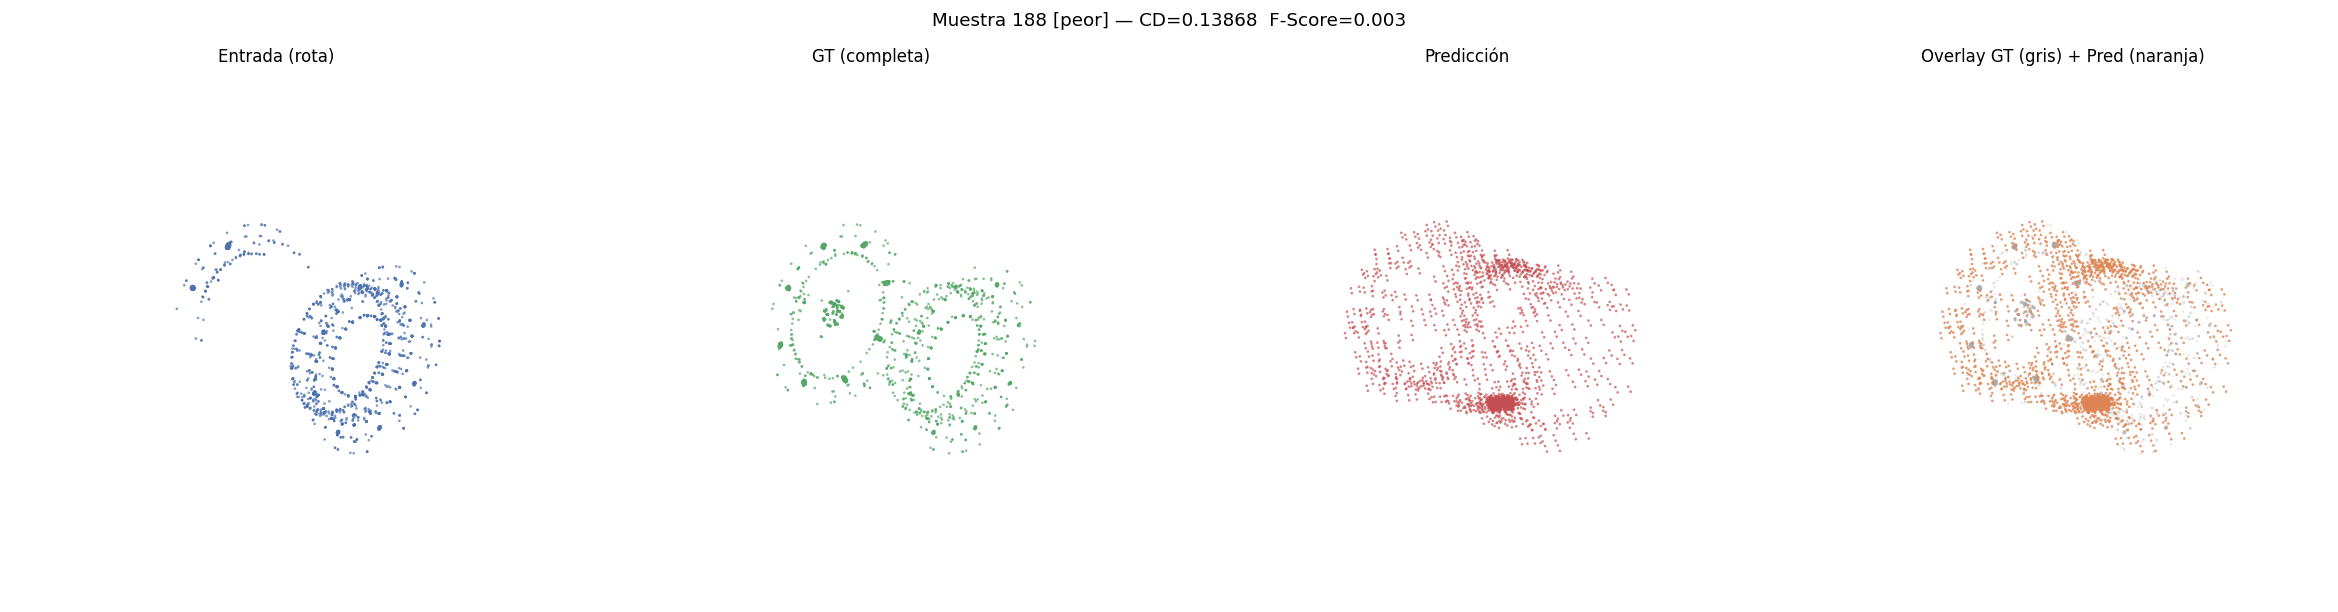

figura_007_peor_60.png


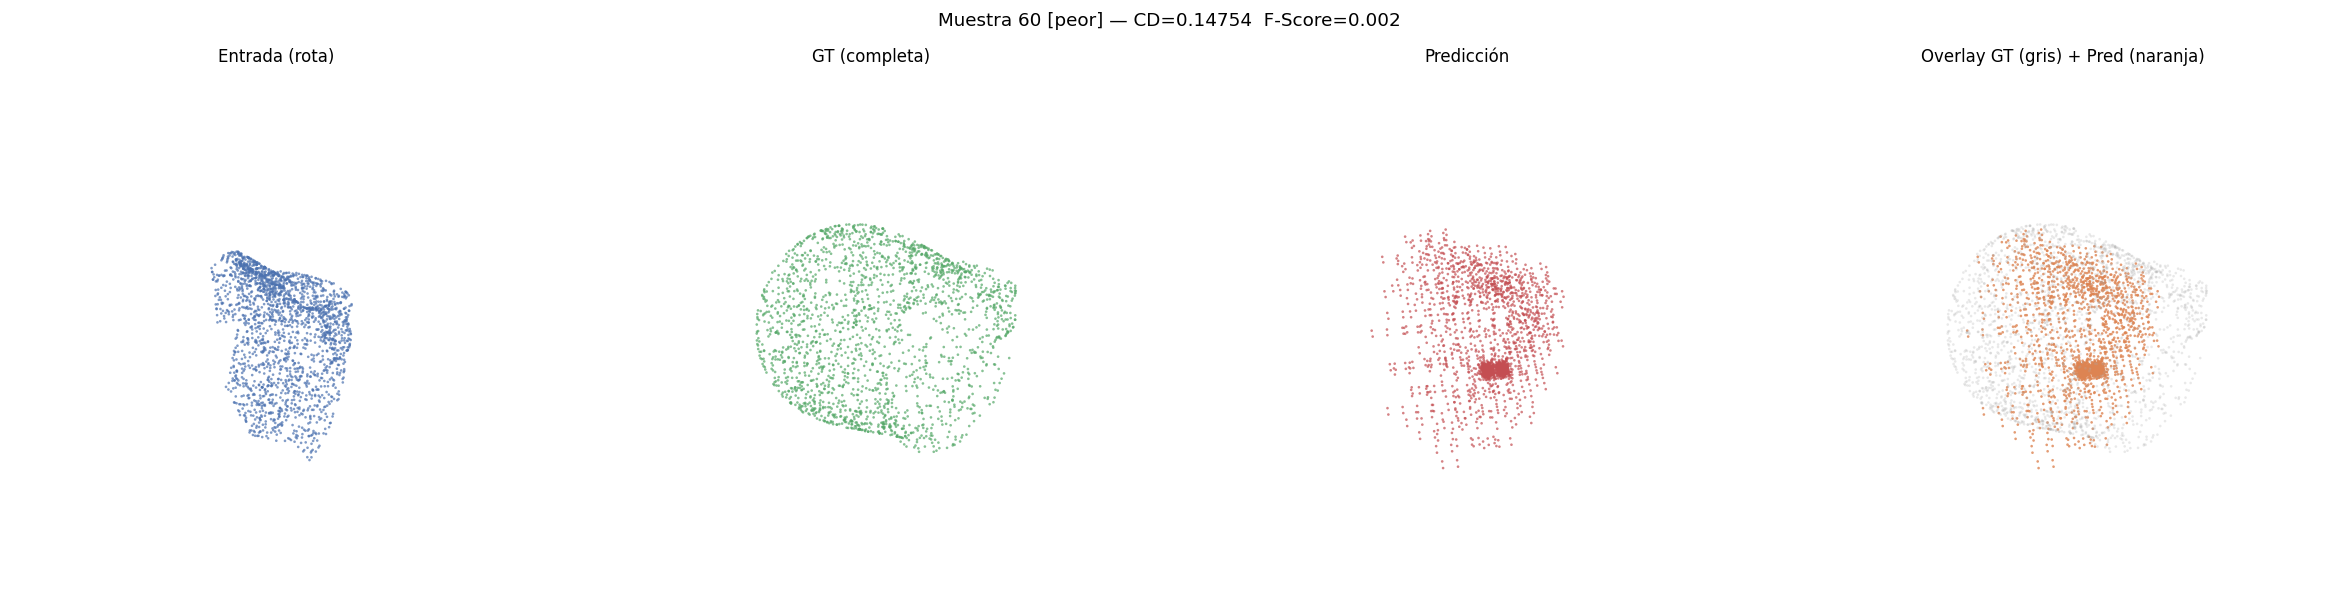

figura_007_peor_63.png


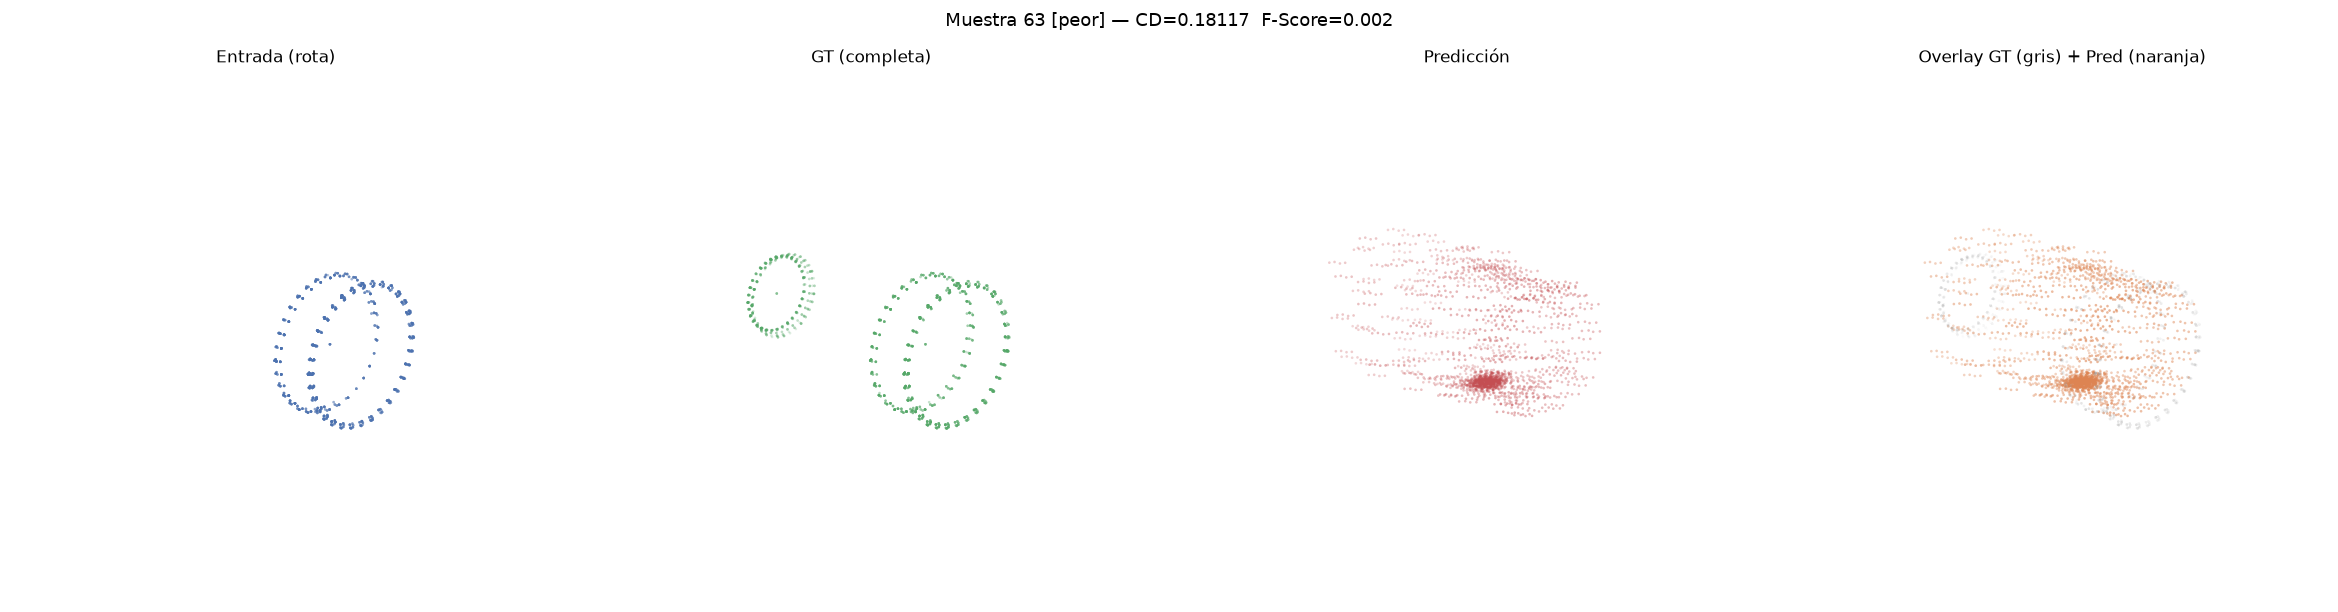

figura_008_peor_124.png


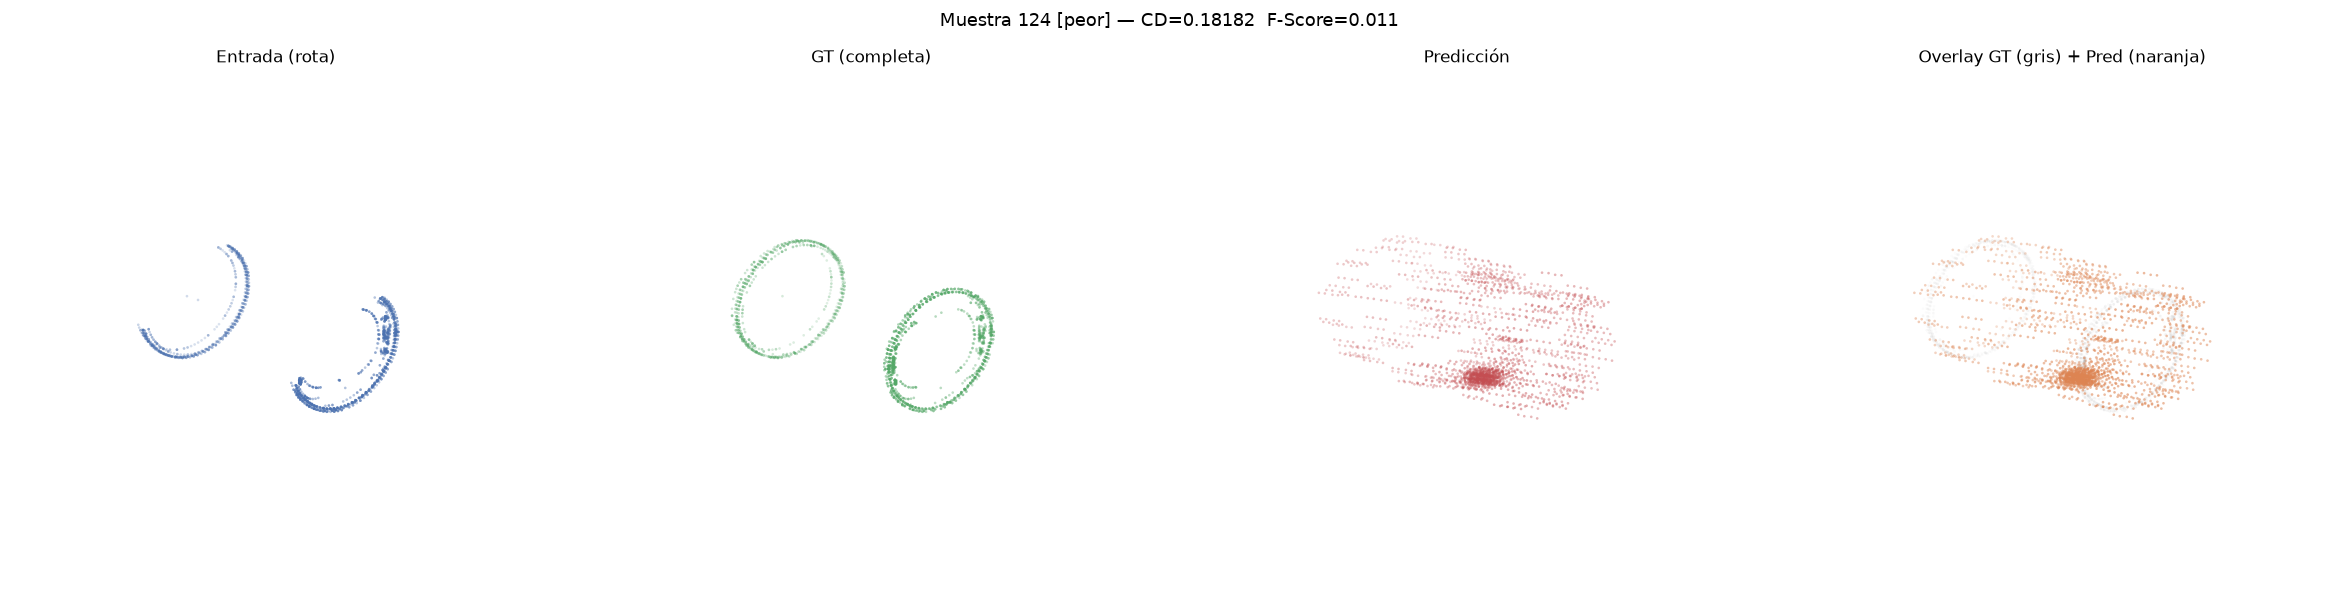

figura_008_peor_193.png


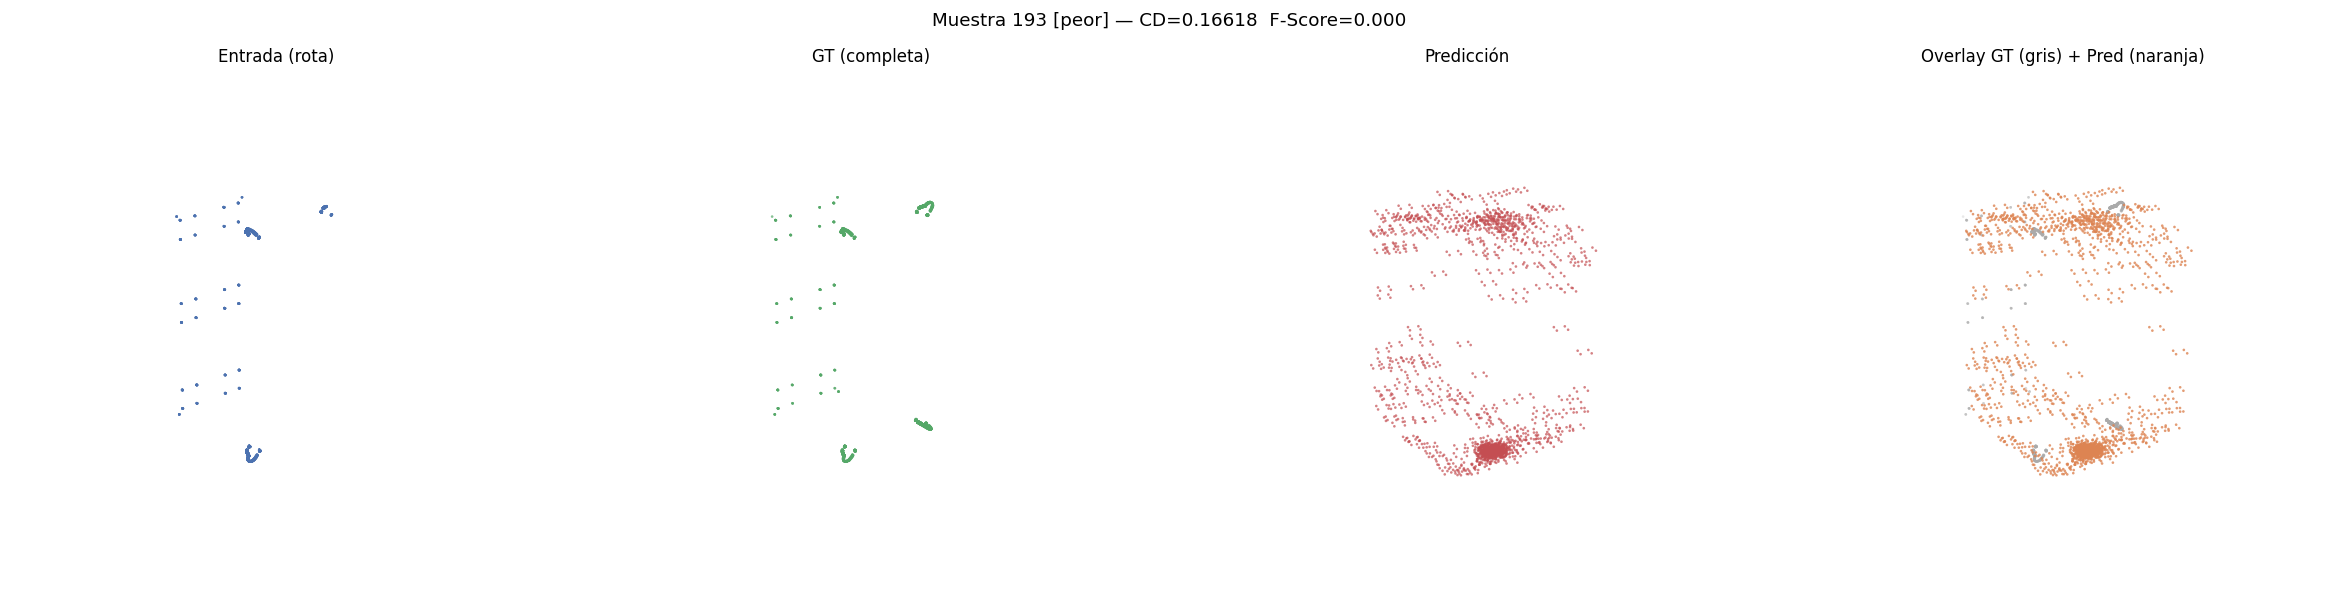

In [11]:
# ── CELDA 11: Ver figuras inline ────────────────────────────────
from IPython.display import Image, display
from pathlib import Path

figuras = sorted(Path('E3/resultados').glob('figura_*.png'))
if not figuras:
    print('No hay figuras. Ejecuta primero la Celda 10.')
else:
    mejores = [f for f in figuras if 'mejor' in f.name]
    peores  = [f for f in figuras if 'peor'  in f.name]

    print(f'=== MEJORES ({len(mejores)}) ===')
    for f in mejores:
        print(f.name)
        display(Image(str(f), width=1000))

    print(f'\n=== PEORES ({len(peores)}) ===')
    for f in peores:
        print(f.name)
        display(Image(str(f), width=1000))

In [12]:
# ── CELDA 12: Visualización 3D interactiva ────────────────────
# Muestra los 3 mejores y 3 peores resultados como nubes de puntos 3D
# que puedes rotar con el ratón en Colab.
#
#   Azul  = entrada rota (lo que ve el modelo)
#   Verde = GT completa  (lo que debería predecir)
#   Rojo  = predicción   (lo que predice)
#
# Si el rojo se superpone bien al verde → el modelo funciona.
# Si el rojo es una nube difusa → el modelo falla.

import subprocess
subprocess.run(['pip', 'install', 'plotly', '--quiet'])

import plotly.graph_objects as go
import numpy as np
import torch
from E3.train import PCN, chamfer_distance
from E3.dataset import construir_dataloaders

# ── Cargar modelo ──────────────────────────────────────────────
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model  = PCN().to(device)
ckpt   = torch.load('E3/checkpoints/best.pt', map_location=device, weights_only=True)
model.load_state_dict(ckpt['model_state_dict'])
model.eval()
print(f'Modelo cargado  —  época {ckpt["epoch"]}')

# ── Inferencia sobre el test set completo ─────────────────────
_, _, test_loader = construir_dataloaders(
    carpetas=['Datos/sintetico/roturas', 'Datos/fantastic_breaks/procesado'],
    batch_size=32, augmentar=False,
)

rotos, gts, preds, cds = [], [], [], []

with torch.no_grad():
    for roto_b, gt_b in test_loader:
        _, pred_b = model(roto_b.to(device))
        pred_b = pred_b.cpu()
        for i in range(len(roto_b)):
            p, g = pred_b[i:i+1], gt_b[i:i+1]
            cd = chamfer_distance(p, g).item()
            rotos.append(roto_b[i].numpy())
            gts.append(gt_b[i].numpy())
            preds.append(pred_b[i].numpy())
            cds.append(cd)

cds_arr = np.array(cds)
orden   = np.argsort(cds_arr)
indices = list(orden[:3]) + list(orden[-3:])
titulos = ['⭐ Mejor 1', '⭐ Mejor 2', '⭐ Mejor 3',
           '❌ Peor 1',  '❌ Peor 2',  '❌ Peor 3']

print(f'CD test — mejor: {cds_arr[orden[0]]:.4f}  |  peor: {cds_arr[orden[-1]]:.4f}  |  media: {cds_arr.mean():.4f}')
print()

# ── Mostrar figura interactiva por muestra ────────────────────
for idx, titulo in zip(indices, titulos):
    roto = rotos[idx]
    gt   = gts[idx]
    pred = preds[idx]
    cd   = cds[idx]

    fig = go.Figure()

    fig.add_trace(go.Scatter3d(
        x=roto[:,0], y=roto[:,1], z=roto[:,2],
        mode='markers',
        marker=dict(size=2, color='#4C72B0', opacity=0.55),
        name='Entrada (rota)',
    ))
    fig.add_trace(go.Scatter3d(
        x=gt[:,0], y=gt[:,1], z=gt[:,2],
        mode='markers',
        marker=dict(size=2, color='#55A868', opacity=0.35),
        name='GT completa',
    ))
    fig.add_trace(go.Scatter3d(
        x=pred[:,0], y=pred[:,1], z=pred[:,2],
        mode='markers',
        marker=dict(size=2, color='#C44E52', opacity=0.85),
        name='Predicción',
    ))

    fig.update_layout(
        title=dict(text=f'{titulo}  —  CD = {cd:.4f}', font=dict(size=14)),
        scene=dict(
            xaxis=dict(range=[-1, 1], showticklabels=False, title=''),
            yaxis=dict(range=[-1, 1], showticklabels=False, title=''),
            zaxis=dict(range=[-1, 1], showticklabels=False, title=''),
            aspectmode='cube',
            bgcolor='#F8F8F8',
        ),
        legend=dict(x=0.01, y=0.99, bgcolor='rgba(255,255,255,0.8)'),
        margin=dict(l=0, r=0, b=0, t=50),
        height=520,
    )
    fig.show()

Modelo cargado  —  época 347

=== Dataset E3 ===
  Total pares    : 2362
  Train          : 1889 (80%)
  Val            : 236   (10%)
  Test           : 237  (10%)
  Batch size     : 32
  Augmentación   : False
CD test — mejor: 0.0290  |  peor: 0.1785  |  media: 0.0627

